In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df  = pd.read_csv('placement.csv')

In [14]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

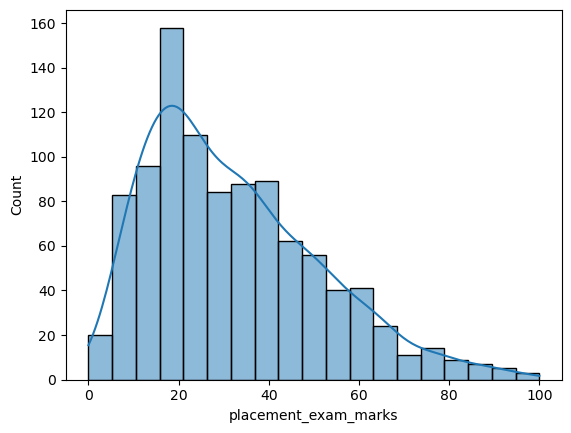

In [6]:
sns.histplot(df['placement_exam_marks'] , kde = True , fill = True)

<Axes: xlabel='placement_exam_marks'>

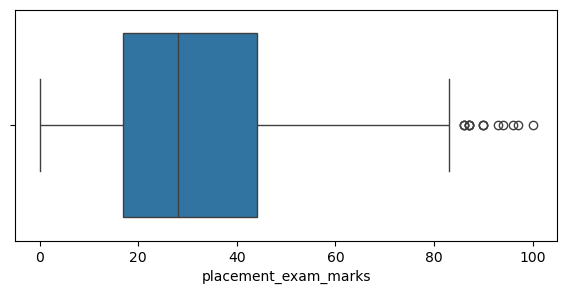

In [7]:
plt.figure(figsize = (7,3))
sns.boxplot( x = df['placement_exam_marks'])

In [8]:
percentile25  = df['placement_exam_marks'].quantile(0.25)
percentile75  = df['placement_exam_marks'].quantile(0.75)

In [9]:
percentile25 

np.float64(17.0)

In [10]:
percentile75

np.float64(44.0)

In [11]:
iqr = percentile75 - percentile25
print(iqr)

27.0


In [16]:
upperlimit = percentile75 + 1.5 *iqr
lowerlimit = percentile25 - 1.5 *iqr

In [17]:
print(upperlimit)
print(lowerlimit)

84.5
-23.5


In [27]:
df[(df['placement_exam_marks']<lowerlimit) | (df['placement_exam_marks']>upperlimit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [28]:
newdf = df[df['placement_exam_marks'] < upperlimit]

In [29]:
newdf.shape

(985, 3)

C:\Users\krati\AppData\Local\Temp\ipykernel_15672\3925628013.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\krati\AppData\Local\Temp\ipykernel_15672\3925628013.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(newdf['placement_exam_marks'])


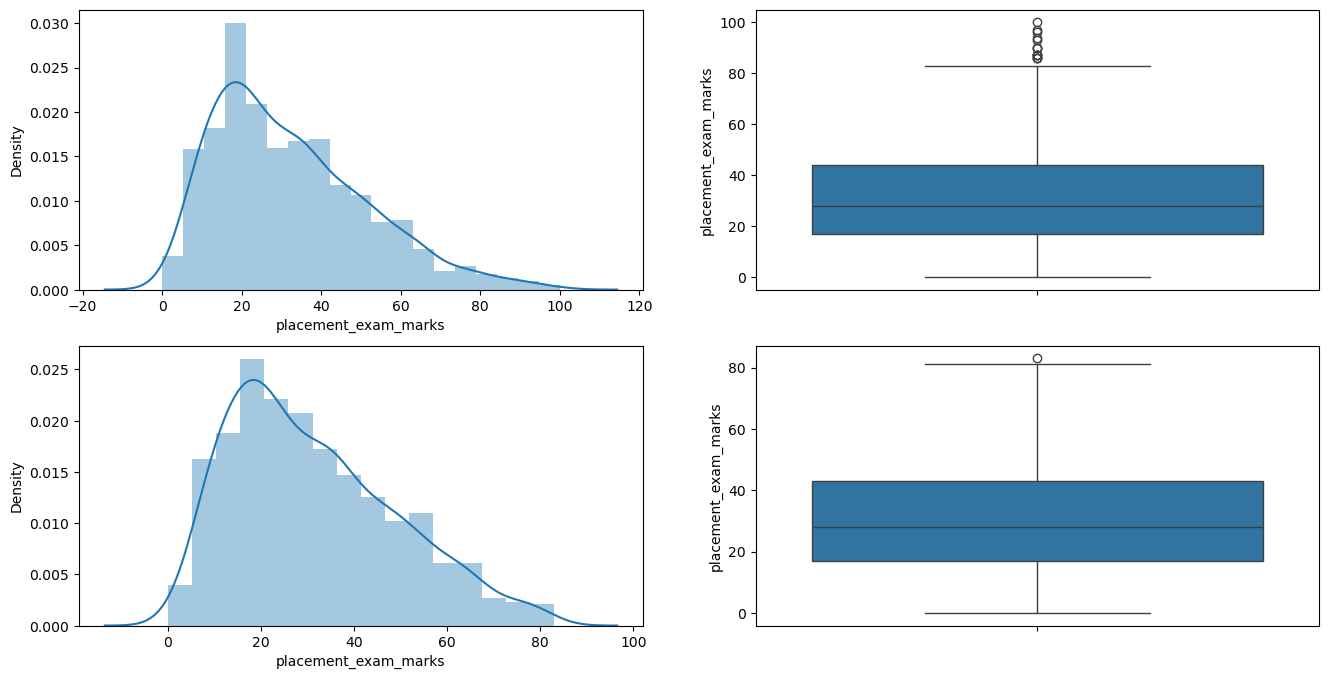

In [33]:
#Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(newdf['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(newdf['placement_exam_marks'])

plt.show()

In [34]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upperlimit,
    upperlimit,
    np.where(
        new_df_cap['placement_exam_marks'] < lowerlimit,
        lowerlimit,
        new_df_cap['placement_exam_marks']
    )
)

In [ ]:
np.where(condtion,true,false)

In [37]:
new_df_cap.shape

(1000, 3)

C:\Users\krati\AppData\Local\Temp\ipykernel_15672\3538926932.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\krati\AppData\Local\Temp\ipykernel_15672\3538926932.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])


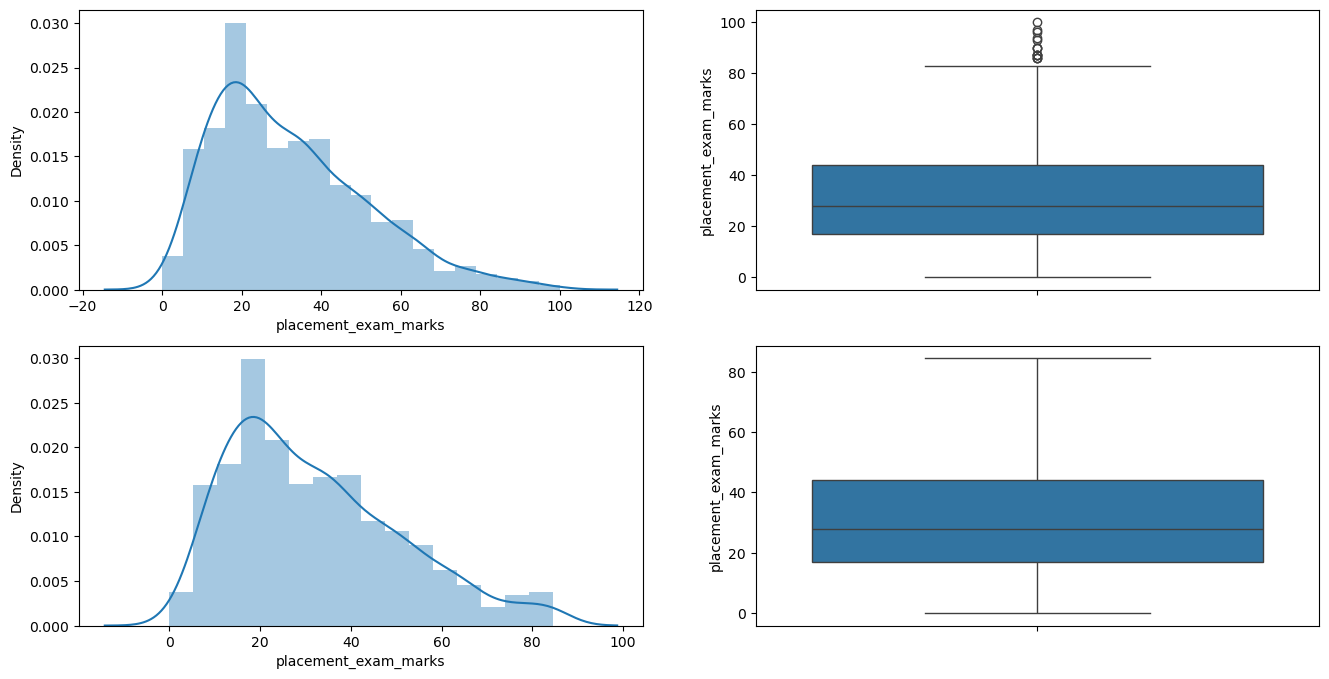

In [38]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()